In [1]:
import sys
sys.path.append("..")

In [2]:
from src.data import load_glass_data

df = load_glass_data(target="Tg")

X = df.drop(columns=["Tg"])
y = df["Tg"]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target range: {y.min():.1f} - {y.max():.1f} °C")

Features: 28
Samples: 55815
Target range: 2.0 - 1222.0 °C


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} °C")
print(f"R²: {r2:.4f}")

RMSE: 33.08 °C
R²: 0.9488


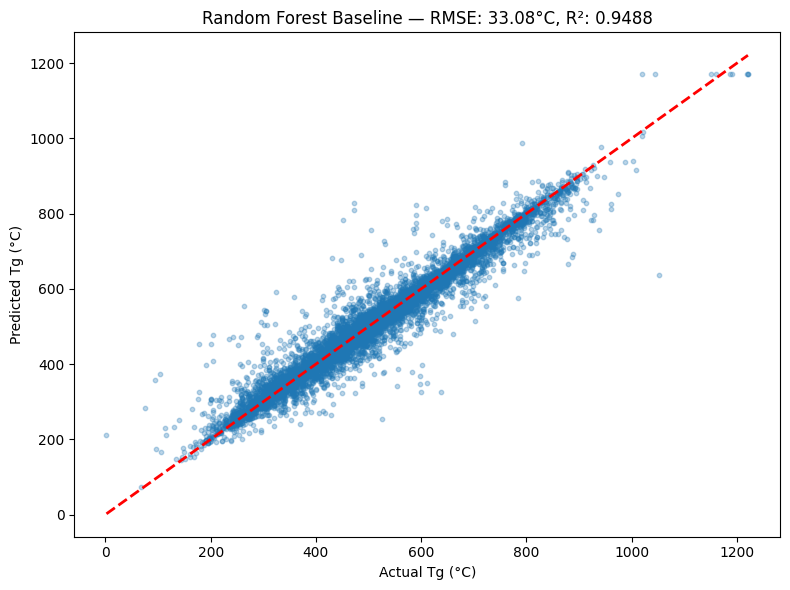

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel("Actual Tg (°C)")
plt.ylabel("Predicted Tg (°C)")
plt.title(f"Random Forest Baseline — RMSE: {rmse:.2f}°C, R²: {r2:.4f}")
plt.tight_layout()
plt.savefig("../outputs/baseline_rf.png", dpi=150)
plt.show()

In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f} °C")
print(f"XGBoost R²: {r2_xgb:.4f}")
print()
print(f"RF RMSE:      {rmse:.2f} °C")
print(f"RF R²:        {r2:.4f}")

XGBoost RMSE: 38.30 °C
XGBoost R²: 0.9313

RF RMSE:      33.08 °C
RF R²:        0.9488


In [6]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [20, 30, 40, None],
    "max_features": [0.3, 0.5, 0.7],
    "min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
y_pred_rf_tuned = rf_search.predict(X_test)
rmse_rf_tuned = root_mean_squared_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
print(f"Tuned RF RMSE: {rmse_rf_tuned:.2f} °C")
print(f"Tuned RF R²:   {r2_rf_tuned:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}
Tuned RF RMSE: 31.06 °C
Tuned RF R²:   0.9548


In [7]:
from xgboost import XGBRegressor

xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print(f"Best params: {xgb_search.best_params_}")
y_pred_xgb_tuned = xgb_search.predict(X_test)
rmse_xgb_tuned = root_mean_squared_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
print(f"Tuned XGBoost RMSE: {rmse_xgb_tuned:.2f} °C")
print(f"Tuned XGBoost R²:   {r2_xgb_tuned:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Tuned XGBoost RMSE: 32.39 °C
Tuned XGBoost R²:   0.9509


In [14]:
lgbm_base = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm_base.fit(X_train, y_train)
y_pred_lgbm_base = lgbm_base.predict(X_test)
rmse_lgbm_base = root_mean_squared_error(y_test, y_pred_lgbm_base)
r2_lgbm_base = r2_score(y_test, y_pred_lgbm_base)
print(f"Baseline LightGBM RMSE: {rmse_lgbm_base:.2f} °C")
print(f"Baseline LightGBM R²:   {r2_lgbm_base:.4f}")

Baseline LightGBM RMSE: 43.04 °C
Baseline LightGBM R²:   0.9133


In [9]:
from lightgbm import LGBMRegressor

lgbm_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "num_leaves": [31, 63, 127],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

lgbm_search.fit(X_train, y_train)

print(f"Best params: {lgbm_search.best_params_}")
y_pred_lgbm = lgbm_search.predict(X_test)
rmse_lgbm = root_mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)
print(f"Tuned LightGBM RMSE: {rmse_lgbm:.2f} °C")
print(f"Tuned LightGBM R²:   {r2_lgbm:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Tuned LightGBM RMSE: 36.37 °C
Tuned LightGBM R²:   0.9381


In [13]:
results = {
    "Baseline RF":       {"RMSE": rmse,           "R2": r2},
    "Baseline XGBoost":  {"RMSE": rmse_xgb,       "R2": r2_xgb},
    "Baseline LightGBM": {"RMSE": rmse_lgbm_base, "R2": r2_lgbm_base},
    "Tuned RF":          {"RMSE": rmse_rf_tuned,  "R2": r2_rf_tuned},
    "Tuned XGBoost":     {"RMSE": rmse_xgb_tuned, "R2": r2_xgb_tuned},
    "Tuned LightGBM":    {"RMSE": rmse_lgbm,      "R2": r2_lgbm},
}

print(f"{'Model':<20} {'RMSE':>10} {'R2':>10}")
print("-" * 42)
for model, metrics in results.items():
    print(f"{model:<20} {metrics['RMSE']:>10.2f} {metrics['R2']:>10.4f}")

Model                      RMSE         R2
------------------------------------------
Baseline RF               33.08     0.9488
Baseline XGBoost          38.30     0.9313
Tuned RF                  31.06     0.9548
Tuned XGBoost             32.39     0.9509
Tuned LightGBM            36.37     0.9381


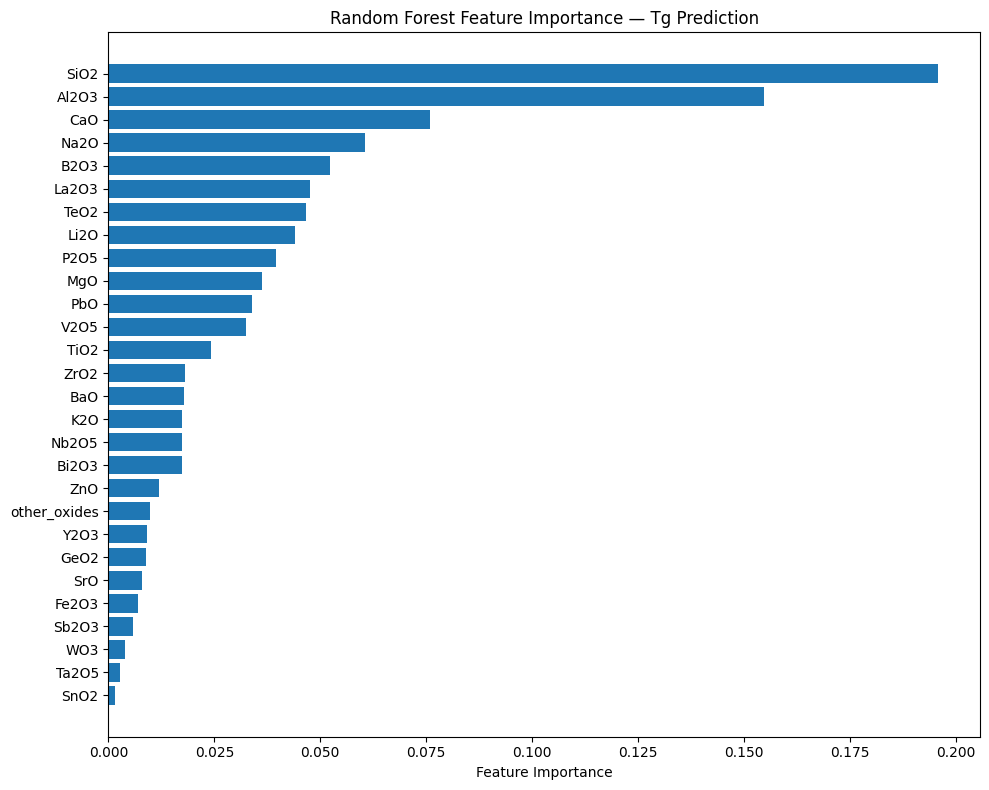

         feature  importance
0           SiO2    0.195922
2          Al2O3    0.154736
4            CaO    0.075839
3           Na2O    0.060521
1           B2O3    0.052192
15         La2O3    0.047632
20          TeO2    0.046730
9           Li2O    0.043943
7           P2O5    0.039586
6            MgO    0.036232
12           PbO    0.033835
21          V2O5    0.032388
11          TiO2    0.024178
13          ZrO2    0.017999
8            BaO    0.017789
5            K2O    0.017389
17         Nb2O5    0.017329
19         Bi2O3    0.017283
10           ZnO    0.011889
27  other_oxides    0.009870
26          Y2O3    0.009179
22          GeO2    0.008916
14           SrO    0.007920
16         Fe2O3    0.006961
18         Sb2O3    0.005716
23           WO3    0.003799
25         Ta2O5    0.002789
24          SnO2    0.001441


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()
importances = rf_search.best_estimator_.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance — Tg Prediction")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

print(importance_df.sort_values("importance", ascending=False).to_string())

In [11]:
for threshold in [90, 95, 99]:
    from src.data import load_glass_data
    df_test = load_glass_data(target="Tg", coverage_threshold=threshold)
    print(f"Threshold {threshold}%: {len(df_test)} rows, other_oxides mean: {df_test['other_oxides'].mean():.2f}%")

Threshold 90%: 55815 rows, other_oxides mean: 0.88%
Threshold 95%: 51895 rows, other_oxides mean: 0.36%
Threshold 99%: 46625 rows, other_oxides mean: 0.05%


In [12]:
from glasspy.data import SciGlass
import pandas as pd

source_check = SciGlass(
    properties_cfg={"keep_all": True},
    compounds_cfg={"keep_all": True},
)
df_check = source_check.data
non_zero_pct = (df_check["compounds"] > 0).mean().sort_values(ascending=False)

# What's between 2% and 5% that we're missing
between = non_zero_pct[(non_zero_pct >= 0.02) & (non_zero_pct < 0.05)]
print(between)

Sb2O3    0.049022
Bi2O3    0.048831
TeO2     0.047076
Se       0.043708
V2O5     0.037650
GeO2     0.035846
WO3      0.035493
Ge       0.031673
BaF2     0.030243
As       0.029618
SnO2     0.027913
As2O3    0.025935
Ta2O5    0.024054
AlF3     0.023863
Y2O3     0.023736
NaF      0.023090
Gd2O3    0.022917
Te       0.022754
dtype: float64


In [ ]:
import sys
sys.path.append("..")

from src.model import save_model
from src.data import get_oxide_features

save_model(
    model=rf_search.best_estimator_,
    path="../outputs/models/tg_rf_tuned.joblib",
    metadata={
        "target": "Tg",
        "features": get_oxide_features() + ["other_oxides"],
        "test_rmse": rmse_rf_tuned,
        "test_r2": r2_rf_tuned,
        "best_params": rf_search.best_params_,
    }
)